# Results & Evaluation

## Set Up, Loading, Parsing

In [2]:
# Install required libraries if not already present
# !pip install pandas scikit-learn seqeval tabulate

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from seqeval.metrics import (
    classification_report as seq_classification_report,
    f1_score as seq_f1,
    precision_score as seq_precision,
    recall_score as seq_recall,
)

print("All imports successful.")

All imports successful.


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
TEXT_NAMES = [
    'Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv', 
    'Juvenal_sat_1_3_GOLD.tsv', 
    'Tacitus_TacHistoriae_TacHist1_GOLD.tsv'
]
PREDICTION_ITERATION = "0"
MODEL_NAMES = [
    "latinBERT",
    "mBERT",
    "mistralNemo/zero-shot",
    "mistralNemo/few-shot",
    "ministral/zero-shot",
    "ministral/few-shot",
    "claude/zero-shot",
    "claude/few-shot"
]

# label normalization maps
# entries are {existing : normalized}
GOLD_TO_NORM = {
    'LOC' : 'GEO',
    'PER' : 'PERS'
}
PRED_TO_NORM = {
    'LOC' : 'GEO',
    'PER' : 'PERS',
}

# color maps
model_color_map = {
    "latinBERT": "#663399",
    "mBERT": "#4169E1",
    "mistralNemo/zero-shot": "#DB7093",
    "mistralNemo/few-shot": "#B22222",
    "ministral/zero-shot": "#3CB371",
    "ministral/few-shot": "#006400",
    "claude/zero-shot": "#F4A460",
    "claude/few-shot": "#A0522D"
}

In [4]:
# Helper functions for sentence reconstruction
def add_sentence_ids(df):
    """Detect sentence boundaries from id resets and add a sentence_id column."""
    sentence_ids = []
    sent_idx = 0
    prev_id = None

    for row_id in df["id"]:
        if prev_id is not None and row_id <= prev_id:
            sent_idx += 1
        sentence_ids.append(sent_idx)
        prev_id = row_id

    df = df.copy()
    df["sentence_id"] = sentence_ids
    return df


def get_sentence_lists(df):
    """Return (gold_sentences, pred_sentences) as lists-of-lists for seqeval."""
    gold, pred = [], []
    for _, sent_df in df.groupby("sentence_id", sort=True):
        gold.append(sent_df["BIO_gold_norm"].tolist())
        pred.append(sent_df["BIO_pred_norm"].tolist())
    return gold, pred


# helper for label normalisation
def normalise_label(label, label_map):
    """Map entity-type strings to a canonical form (e.g. PERS -> PER)."""
    if label == 'O':
        return label
    prefix, etype = label.split('-', 1)
    return f'{prefix}-{label_map.get(etype, etype)}'

In [5]:
# load into data frams
df_dictionary = {}

for model in MODEL_NAMES:
    for text in TEXT_NAMES:
        
        tsv_path = f"predictions_{PREDICTION_ITERATION}_{model}/{text}"
        df = pd.read_csv(tsv_path, sep="\t", quoting=3, dtype=str, comment='#')

        # force ID to numeric and drop rows where labels are missing
        df["id"] = pd.to_numeric(df["id"], errors="coerce")
        print(f"  - {df['BIO_gold'].isna().sum()} tokens with missing gold labels.")
        df = df.dropna(subset=['BIO_gold', 'BIO_pred'])

        df = add_sentence_ids(df)

        # normalize labels
        df['BIO_gold_norm'] = df['BIO_gold'].apply(
            lambda lbl: normalise_label(lbl, GOLD_TO_NORM)
        )
        df['BIO_pred_norm'] = df['BIO_pred'].apply(
            lambda lbl: normalise_label(lbl, PRED_TO_NORM)
        )

        df_dictionary[(model, text)] = df

        print(f"Loaded {model} predictions for {text}."
              f'({len(df)} tokens, {df["sentence_id"].nunique()} sentences)')

print(df_dictionary.keys())

  - 0 tokens with missing gold labels.
Loaded latinBERT predictions for Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv.(3754 tokens, 219 sentences)
  - 0 tokens with missing gold labels.
Loaded latinBERT predictions for Juvenal_sat_1_3_GOLD.tsv.(4463 tokens, 281 sentences)
  - 157 tokens with missing gold labels.
Loaded latinBERT predictions for Tacitus_TacHistoriae_TacHist1_GOLD.tsv.(11983 tokens, 503 sentences)
  - 0 tokens with missing gold labels.
Loaded mBERT predictions for Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv.(3754 tokens, 219 sentences)
  - 0 tokens with missing gold labels.
Loaded mBERT predictions for Juvenal_sat_1_3_GOLD.tsv.(4463 tokens, 281 sentences)
  - 157 tokens with missing gold labels.
Loaded mBERT predictions for Tacitus_TacHistoriae_TacHist1_GOLD.tsv.(11983 tokens, 503 sentences)
  - 0 tokens with missing gold labels.
Loaded mistralNemo/zero-shot predictions for Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv.(3754 tokens, 219 sentences)
  - 0 tokens with missing gold la

In [6]:
# sanity checks and label inventory
for (model, text), df in df_dictionary.items():
    print(f"\n── {model} / {text} ──")
    print(f"=== before normalization ===")
    print(f"  gold: {sorted(df['BIO_gold'].dropna().unique())}")
    print(f"  pred: {sorted(df['BIO_pred'].dropna().unique())}")
    print(f"=== after normalization ===")
    print(f"  gold: {sorted(df['BIO_gold_norm'].dropna().unique())}")
    print(f"  pred: {sorted(df['BIO_pred_norm'].dropna().unique())}")


── latinBERT / Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv ──
=== before normalization ===
  gold: ['B-GRP', 'B-LOC', 'B-PERS', 'I-GRP', 'I-LOC', 'I-PERS', 'O']
  pred: ['B-GRP', 'B-LOC', 'B-PERS', 'I-PERS', 'O']
=== after normalization ===
  gold: ['B-GEO', 'B-GRP', 'B-PERS', 'I-GEO', 'I-GRP', 'I-PERS', 'O']
  pred: ['B-GEO', 'B-GRP', 'B-PERS', 'I-PERS', 'O']

── latinBERT / Juvenal_sat_1_3_GOLD.tsv ──
=== before normalization ===
  gold: ['B-GEO', 'B-GRP', 'B-PER', 'I-GEO', 'I-GRP', 'I-PER', 'O']
  pred: ['B-GRP', 'B-LOC', 'B-PERS', 'I-LOC', 'I-PERS', 'O']
=== after normalization ===
  gold: ['B-GEO', 'B-GRP', 'B-PERS', 'I-GEO', 'I-GRP', 'I-PERS', 'O']
  pred: ['B-GEO', 'B-GRP', 'B-PERS', 'I-GEO', 'I-PERS', 'O']

── latinBERT / Tacitus_TacHistoriae_TacHist1_GOLD.tsv ──
=== before normalization ===
  gold: ['B-DATE', 'B-GEO', 'B-GRP', 'B-PER', 'I-DATE', 'I-GEO', 'I-PER', 'O']
  pred: ['B-GRP', 'B-LOC', 'B-PERS', 'I-LOC', 'I-PERS', 'O']
=== after normalization ===
  gold: ['B-DATE', 'B-

## Token-level

In [7]:
token_results = []

In [8]:
for (model, text), df in df_dictionary.items():
    gold_flat = df['BIO_gold_norm'].tolist()
    pred_flat = df['BIO_pred_norm'].tolist()
    all_labels = sorted(set(gold_flat + pred_flat))
    all_labels = [label for label in set(gold_flat + pred_flat)]

    acc    = accuracy_score(gold_flat, pred_flat)
    report = classification_report(
        gold_flat, pred_flat, labels=all_labels,
        output_dict=True, zero_division=0
    )

    print(f"\n{'='*60}")
    print(f'  Model: {model}  |  Text: {text}')
    print(f'  Token Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f"{'='*60}")
    print(classification_report(gold_flat, pred_flat, labels=all_labels, zero_division=0))

    label_f1s = {
        f'token_f1_{lbl}': report[lbl]['f1-score']
        for lbl in all_labels if lbl in report
    }
    token_results.append({
        'model':                  model,
        'text':                   text,
        'token_accuracy':         acc,
        'token_precision_macro':  report['macro avg']['precision'],
        'token_recall_macro':     report['macro avg']['recall'],
        'token_f1_macro':         report['macro avg']['f1-score'],
        'token_f1_weighted':      report['weighted avg']['f1-score'],
        **label_f1s,
    })


  Model: latinBERT  |  Text: Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv
  Token Accuracy: 0.9875 (98.75%)
              precision    recall  f1-score   support

       B-GRP       0.90      0.38      0.53        24
      B-PERS       0.98      0.79      0.88        76
      I-PERS       0.78      1.00      0.88        18
       I-GRP       0.00      0.00      0.00         3
       I-GEO       0.00      0.00      0.00         4
       B-GEO       0.75      0.43      0.55        14
           O       0.99      1.00      0.99      3615

    accuracy                           0.99      3754
   macro avg       0.63      0.51      0.55      3754
weighted avg       0.99      0.99      0.99      3754


  Model: latinBERT  |  Text: Juvenal_sat_1_3_GOLD.tsv
  Token Accuracy: 0.9608 (96.08%)
              precision    recall  f1-score   support

       B-GRP       0.60      0.42      0.49        36
      B-PERS       0.82      0.57      0.67       143
      I-PERS       0.00      0.00      0.00  

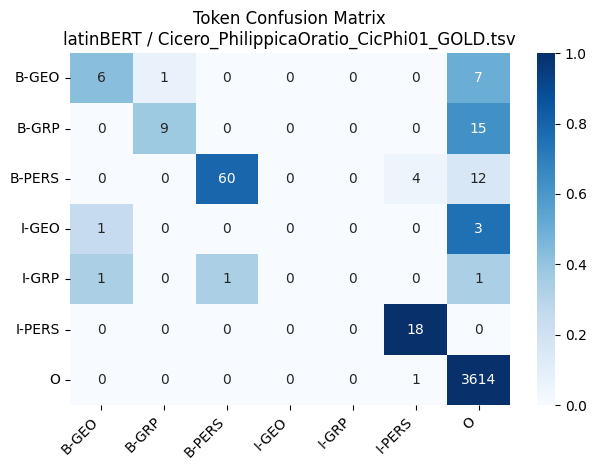

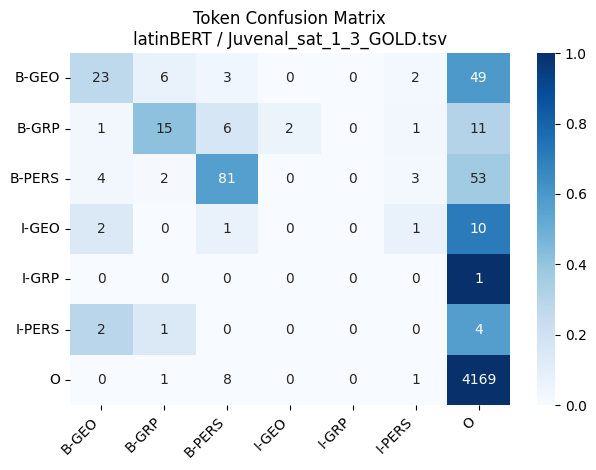

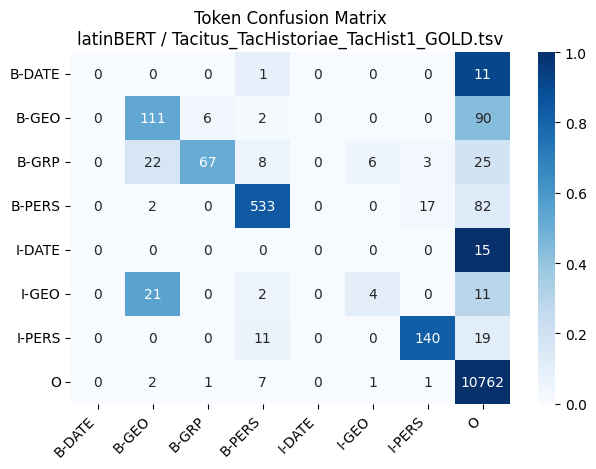

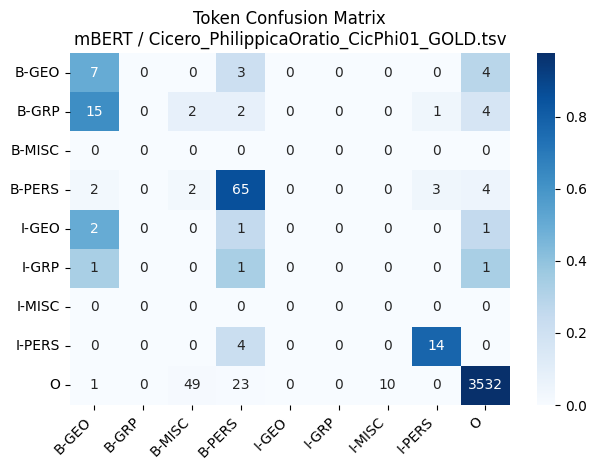

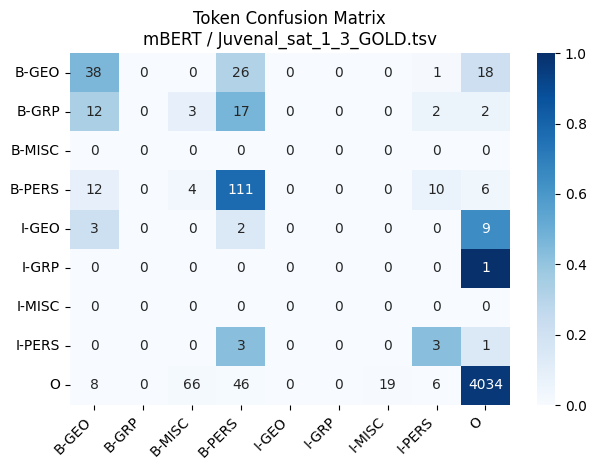

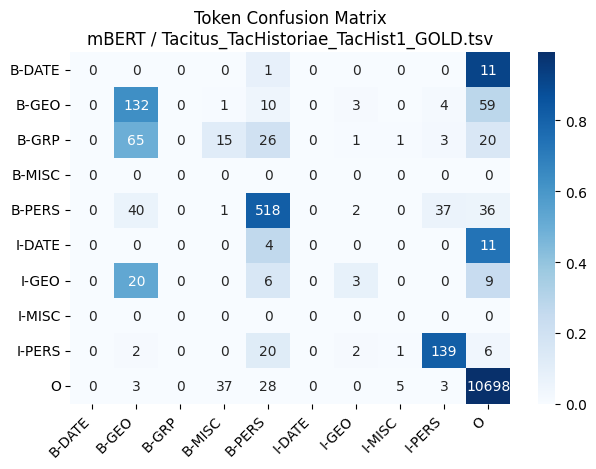

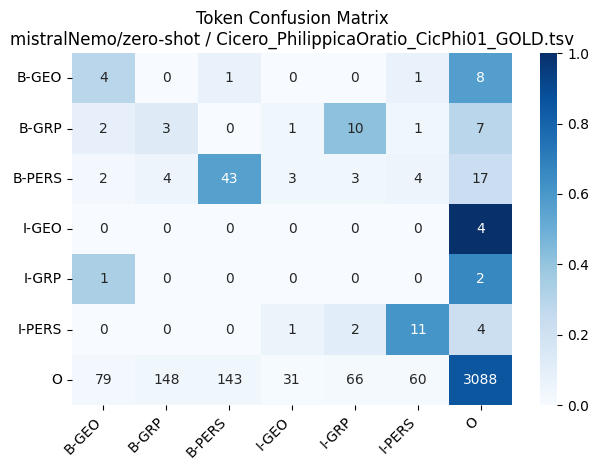

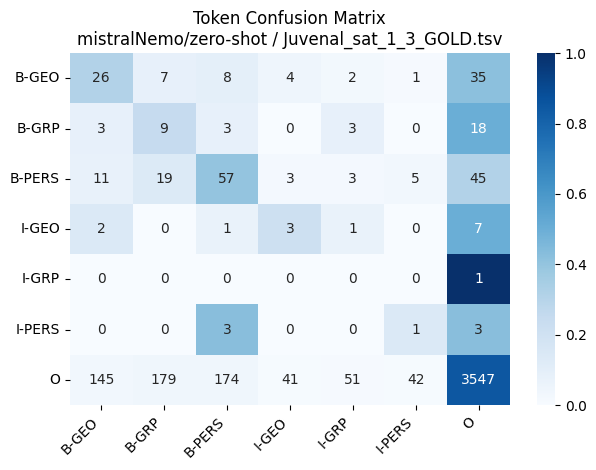

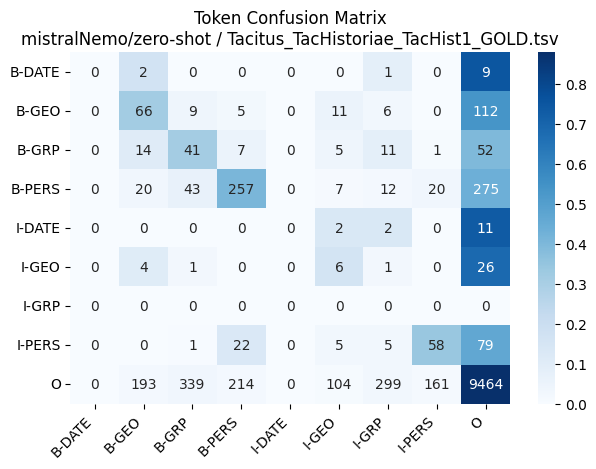

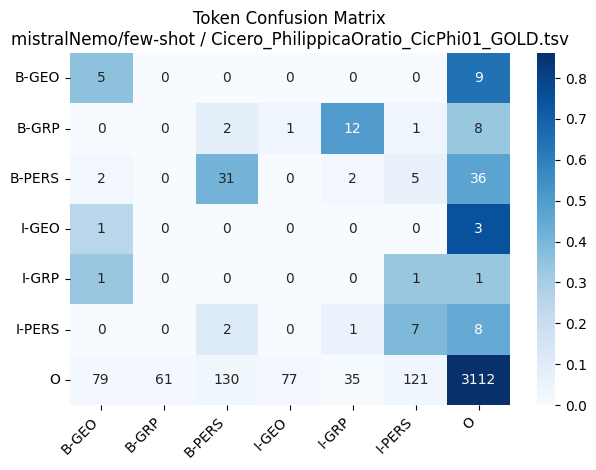

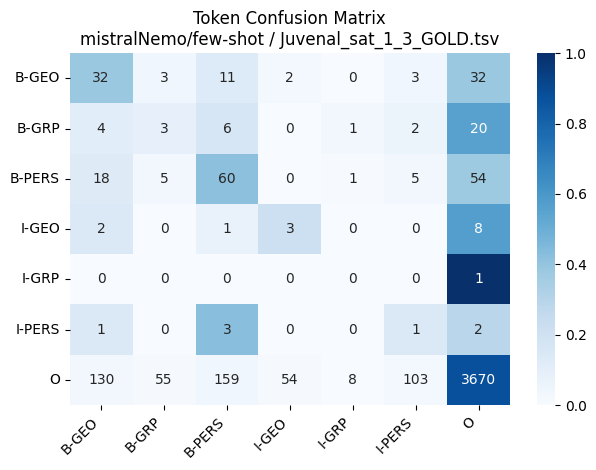

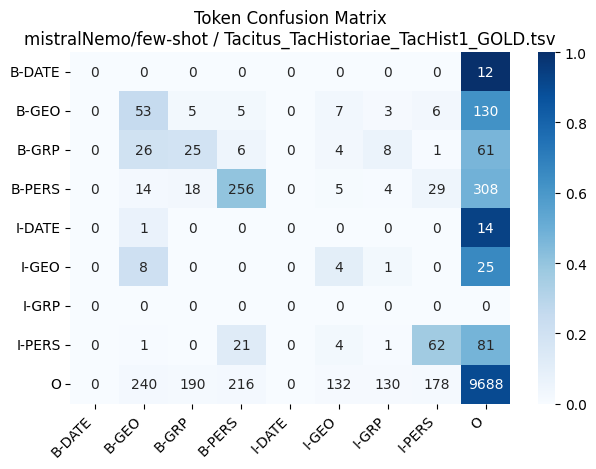

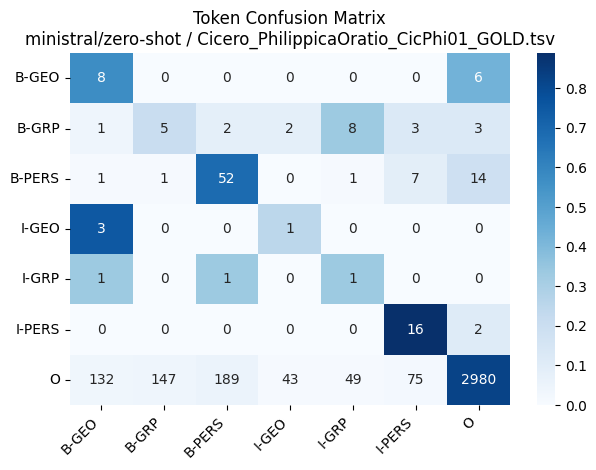

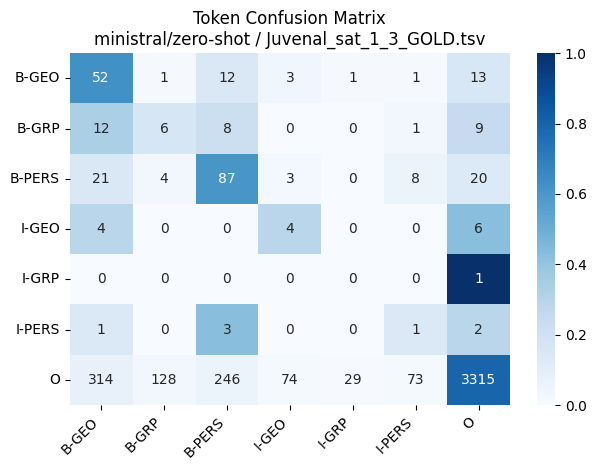

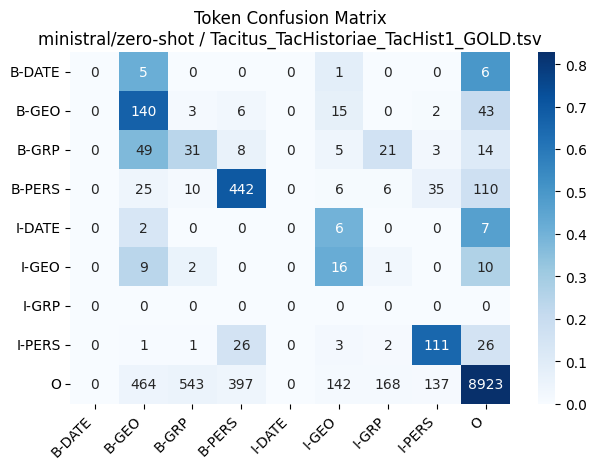

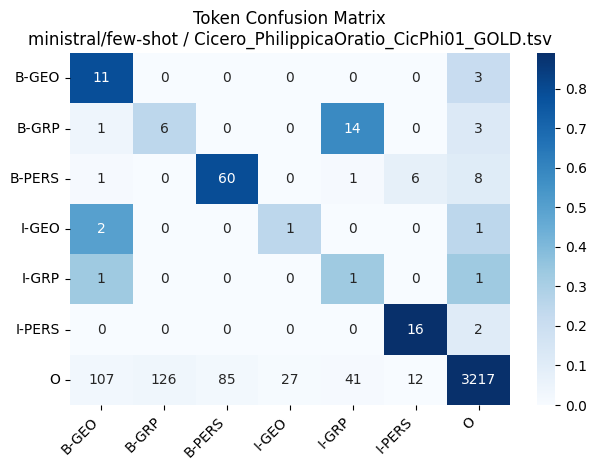

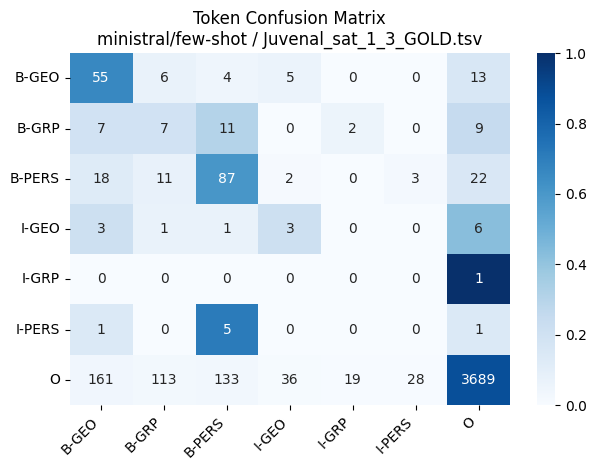

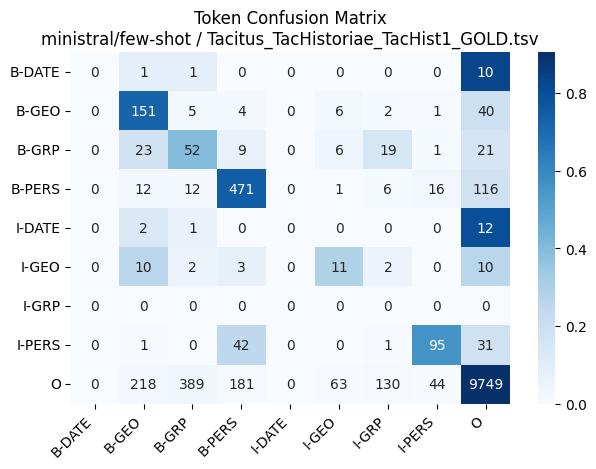

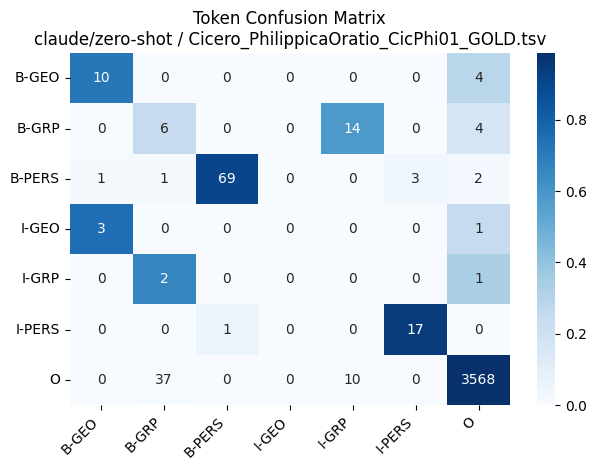

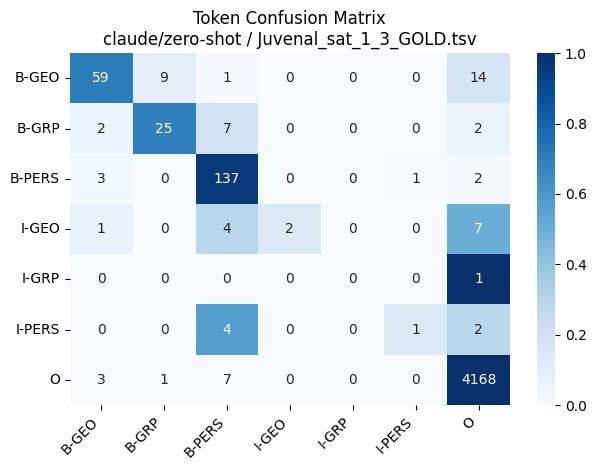

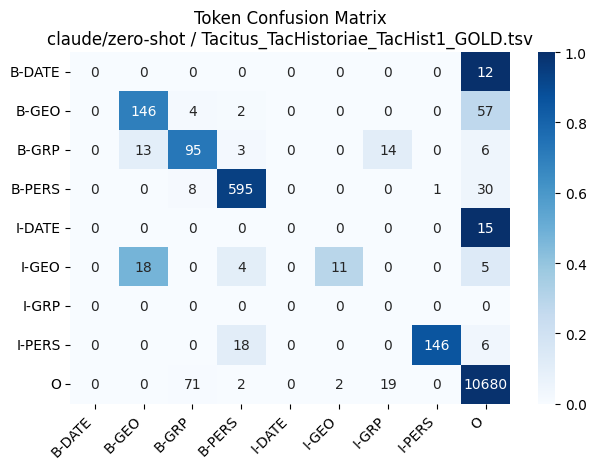

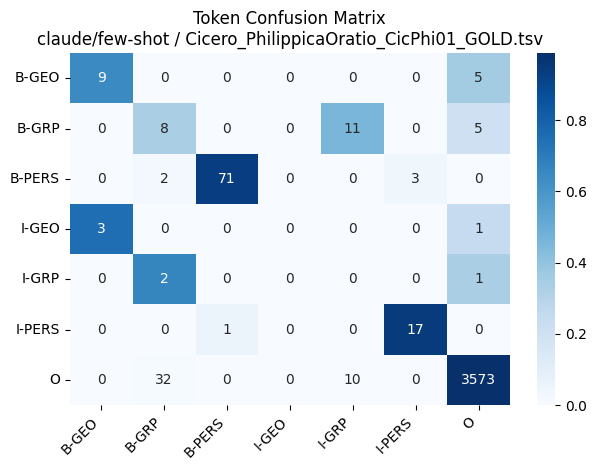

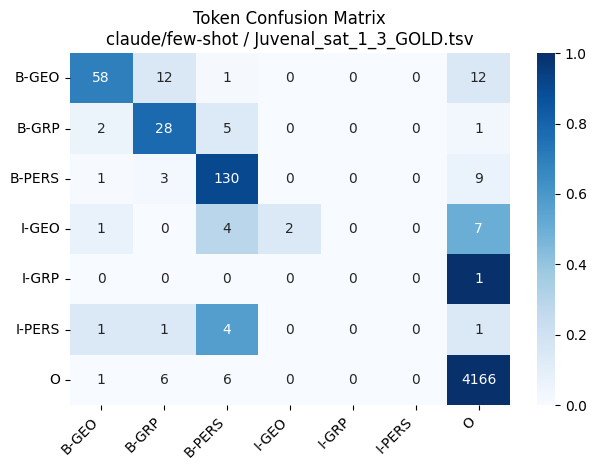

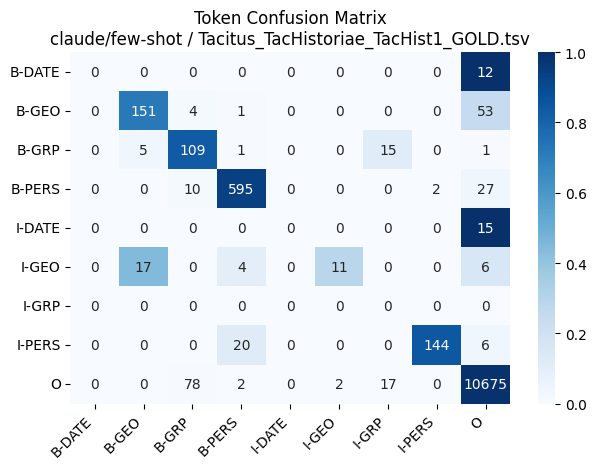

In [9]:
# Confusion matrix — one figure per (model, text)
for (model, text), df in df_dictionary.items():
    gold_flat  = df['BIO_gold_norm'].tolist()
    pred_flat  = df['BIO_pred_norm'].tolist()
    all_labels = sorted(set(gold_flat + pred_flat))

    # color with normalized, annotate with count
    cm  = confusion_matrix(gold_flat, pred_flat, labels=all_labels)
    cm_norm = confusion_matrix(gold_flat, pred_flat, labels=all_labels, normalize='true')

    sns.heatmap(
        cm_norm, 
        annot=cm, 
        fmt='g', cmap='Blues', 
        xticklabels=all_labels, 
        yticklabels=all_labels
    )

    plt.title(f'Token Confusion Matrix\n{model} / {text}')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Span-Level

In [10]:
span_results = []

micro_macro_results = []

In [11]:
for (model, text), df in df_dictionary.items():
    gold_sents, pred_sents = get_sentence_lists(df)

    sp = seq_precision(gold_sents, pred_sents)
    sr = seq_recall(gold_sents, pred_sents)
    sf = seq_f1(gold_sents, pred_sents, zero_division=0)

    print(f"\n{'='*60}")
    print(f'  Model: {model}  |  Text: {text}')
    print(f'  Span  Precision: {sp:.4f}  Recall: {sr:.4f}  F1: {sf:.4f}')
    print(f"{'='*60}")
    print(seq_classification_report(gold_sents, pred_sents, zero_division=0))

    report_dict = seq_classification_report(
        gold_sents, pred_sents, output_dict=True, zero_division=0
    )

    micro_macro_results.append({
        'model': model,
        'text': text,
        'micro_avg_f1': report_dict['micro avg']['f1-score'],
        'macro_avg_f1': report_dict['macro avg']['f1-score'],
        })

    entity_f1s = {
        f'span_f1_{etype}': scores['f1-score']
        for etype, scores in report_dict.items()
        if etype not in ('macro avg', 'weighted avg', 'micro avg')
    }
    span_results.append({
        'model':          model,
        'text':           text,
        'span_precision': sp,
        'span_recall':    sr,
        'span_f1':        sf,
        **entity_f1s,
    })



  Model: latinBERT  |  Text: Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv
  Span  Precision: 0.8875  Recall: 0.6228  F1: 0.7320
              precision    recall  f1-score   support

         GEO       0.75      0.43      0.55        14
         GRP       0.90      0.38      0.53        24
        PERS       0.90      0.74      0.81        76

   micro avg       0.89      0.62      0.73       114
   macro avg       0.85      0.51      0.63       114
weighted avg       0.88      0.62      0.72       114


  Model: latinBERT  |  Text: Juvenal_sat_1_3_GOLD.tsv
  Span  Precision: 0.7108  Recall: 0.4354  F1: 0.5400
              precision    recall  f1-score   support

         GEO       0.62      0.24      0.34        88
         GRP       0.60      0.41      0.48        37
        PERS       0.77      0.56      0.65       146

   micro avg       0.71      0.44      0.54       271
   macro avg       0.66      0.40      0.49       271
weighted avg       0.70      0.44      0.53       271


  

### Class Imbalance: Difference between Micro- and Macro- Averages

In [12]:
# take micro and macro averages for each model/text into a dataframe
micro_macro_results_df = pd.DataFrame(micro_macro_results)

# compute difference between micro and macro F1 for each row
micro_macro_results_df['f1_diff'] = (
    micro_macro_results_df['micro_avg_f1'] - micro_macro_results_df['macro_avg_f1']
)

# collect differences for each model across texts
model_diffs = micro_macro_results_df.groupby('model')['f1_diff'].mean().sort_values(ascending=False).to_dict()
print("\nAverage difference between micro and macro F1 by model:")
for model, diff in model_diffs.items():
    print(f"  {model}: {diff:.4f}")


Average difference between micro and macro F1 by model:
  mBERT: 0.2529
  claude/few-shot: 0.1332
  claude/zero-shot: 0.1323
  latinBERT: 0.1315
  ministral/few-shot: 0.0841
  ministral/zero-shot: 0.0694
  mistralNemo/few-shot: 0.0683
  mistralNemo/zero-shot: 0.0520


## Errors

| Category | Gold | Pred | Meaning |
|---|---|---|---|
| **False Negative** | B/I-X | O | Entity missed entirely |
| **False Positive** | O | B/I-X | Hallucinated entity |
| **Type Error** | B/I-**X** | B/I-**Y** | Span found, wrong type |
| **BIO Error** | B-X | I-X (or vice-versa) | Span found, wrong BIO tag |

In [13]:
# error categorization helper
def error_category(gold, pred):
    """Classify a single token-level mismatch into a diagnostic bucket."""
    if gold == pred:
        return None
    g_o, p_o = gold == 'O', pred == 'O'
    if not g_o and p_o:
        return 'False Negative (missed entity)'
    if g_o and not p_o:
        return 'False Positive (hallucinated entity)'
    _, g_type = gold.split('-', 1)
    _, p_type = pred.split('-', 1)
    if g_type != p_type:
        return 'Type Error'
    return 'BIO Tag Error (B vs I mismatch)'

In [14]:
all_mistakes = []
for (model, text), df in df_dictionary.items():
    df = df.copy()
    df['error_category'] = df.apply(
        lambda r: error_category(r['BIO_gold_norm'], r['BIO_pred_norm']), axis=1
    )
    mistakes = df[df['error_category'].notna()].copy()
    mistakes['model'] = model
    mistakes['text']  = text
    all_mistakes.append(mistakes)

    print(f'\n── {model} / {text} ──')
    print(f'   Mismatches: {len(mistakes)} / {len(df)} tokens')
    print(mistakes['error_category'].value_counts().to_string())

mistakes_df = pd.concat(all_mistakes, ignore_index=True)


── latinBERT / Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv ──
   Mismatches: 47 / 3754 tokens
error_category
False Negative (missed entity)          38
BIO Tag Error (B vs I mismatch)          5
Type Error                               3
False Positive (hallucinated entity)     1

── latinBERT / Juvenal_sat_1_3_GOLD.tsv ──
   Mismatches: 175 / 4463 tokens
error_category
False Negative (missed entity)          128
Type Error                               32
False Positive (hallucinated entity)     10
BIO Tag Error (B vs I mismatch)           5

── latinBERT / Tacitus_TacHistoriae_TacHist1_GOLD.tsv ──
   Mismatches: 366 / 11983 tokens
error_category
False Negative (missed entity)          253
Type Error                               52
BIO Tag Error (B vs I mismatch)          49
False Positive (hallucinated entity)     12

── mBERT / Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv ──
   Mismatches: 136 / 3754 tokens
error_category
False Positive (hallucinated entity)    83
Type Error           

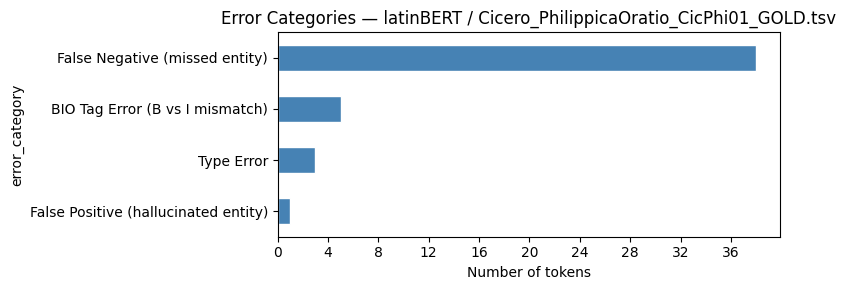

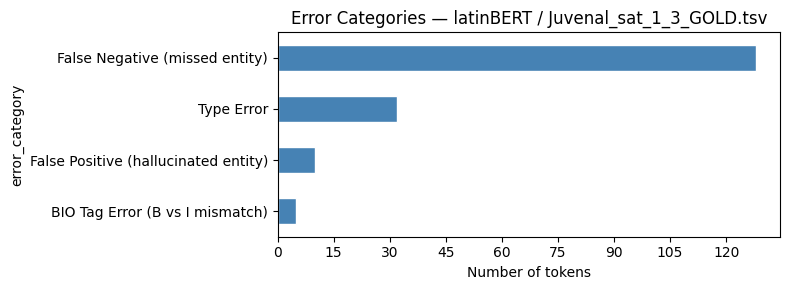

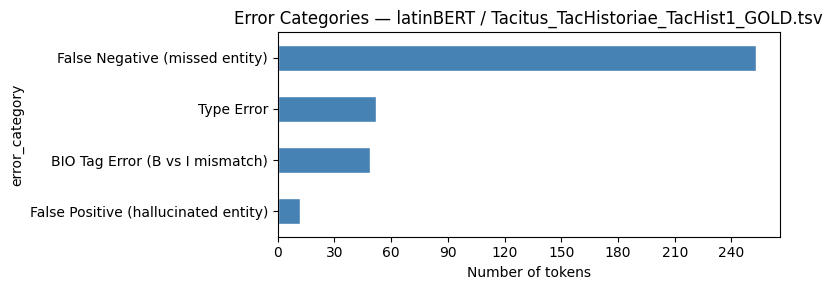

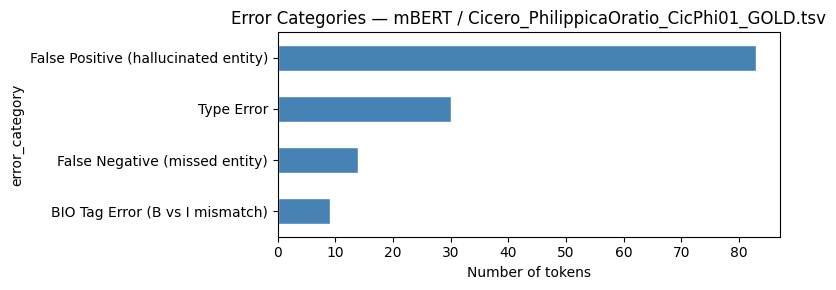

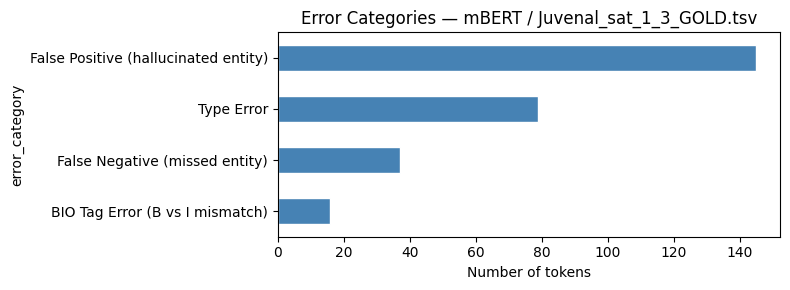

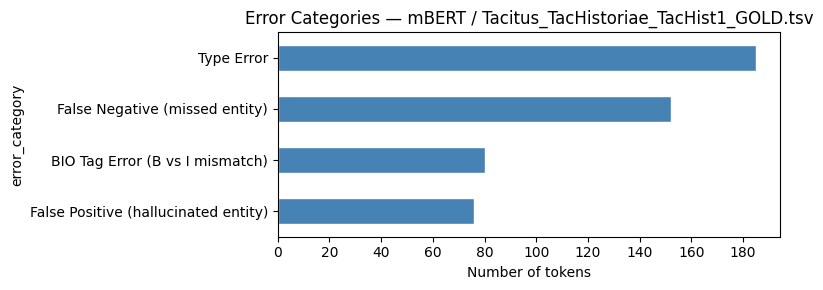

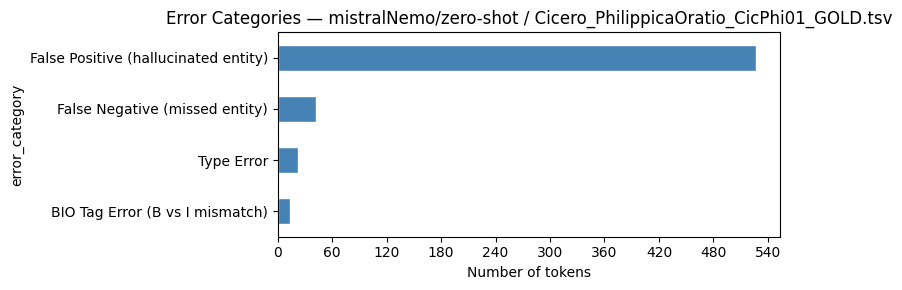

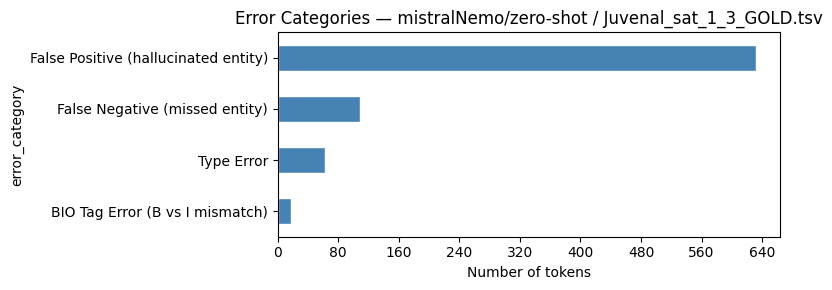

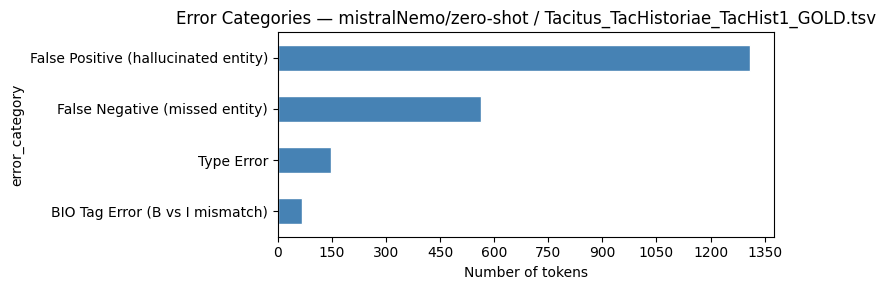

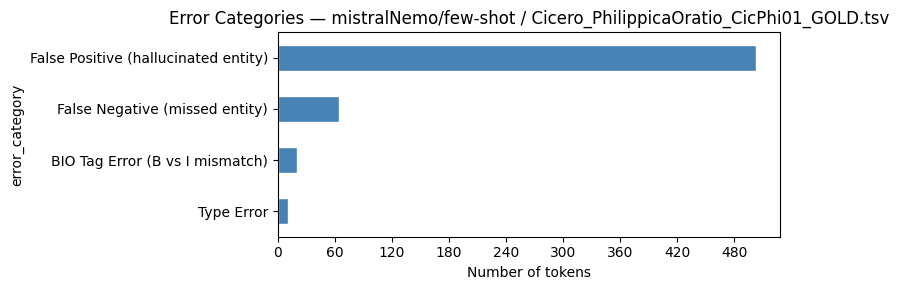

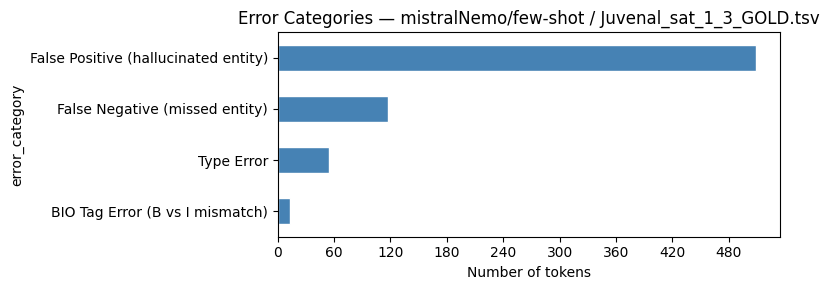

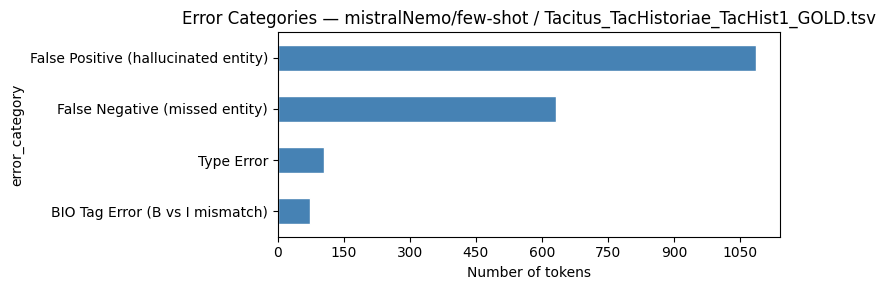

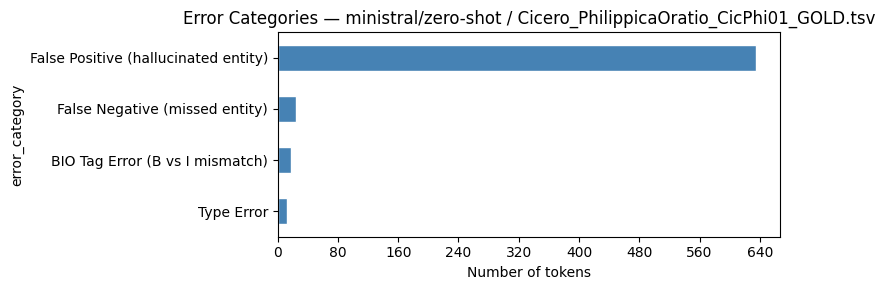

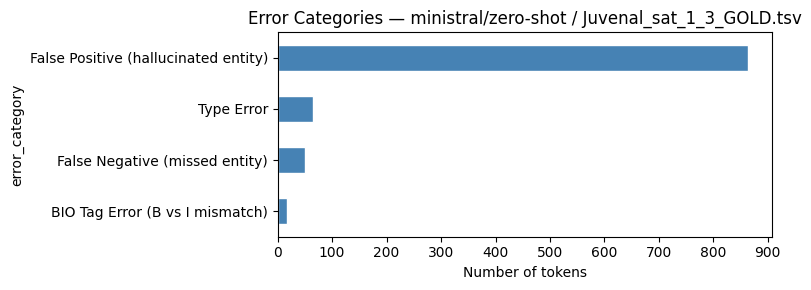

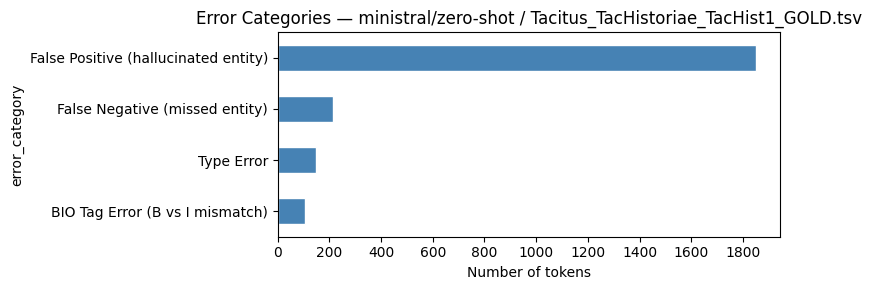

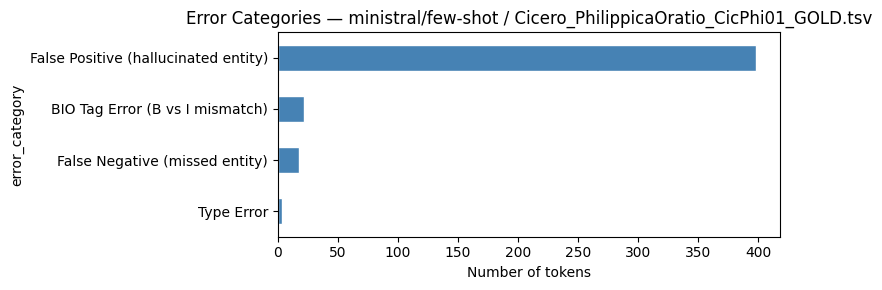

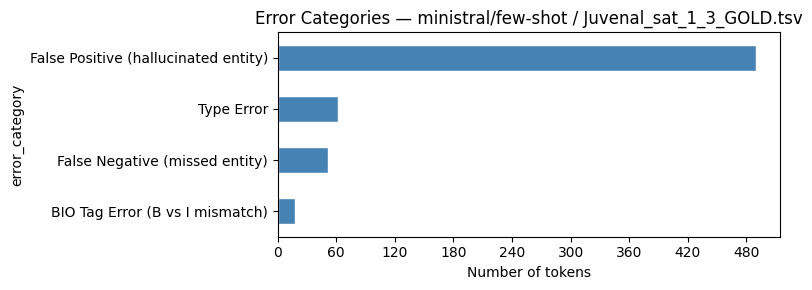

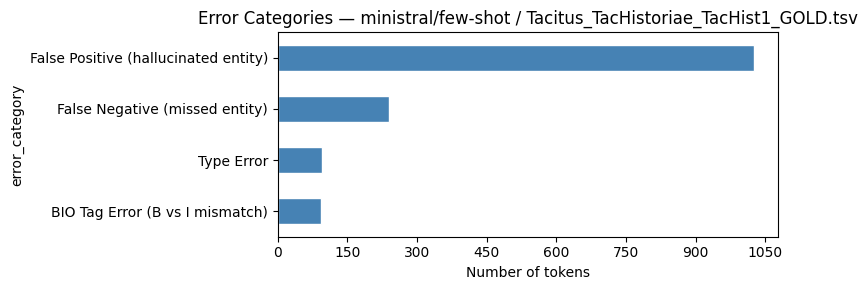

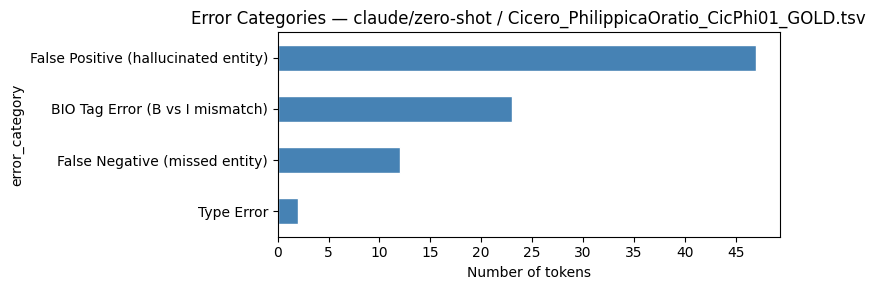

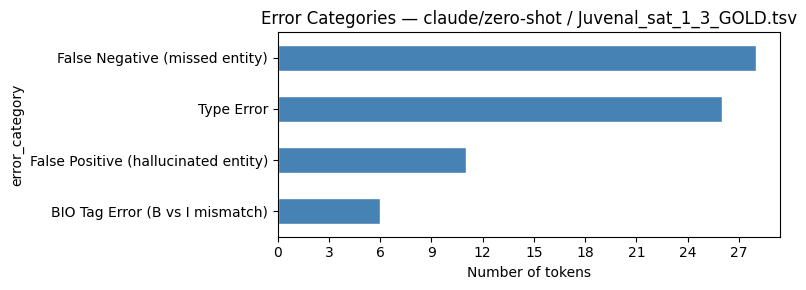

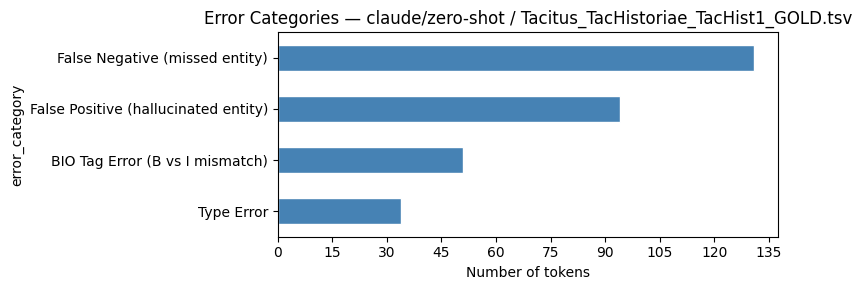

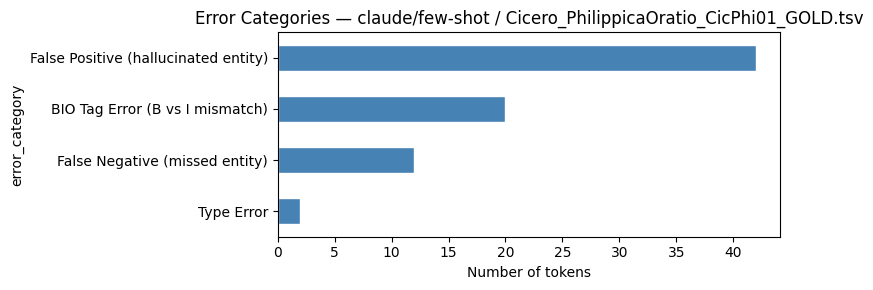

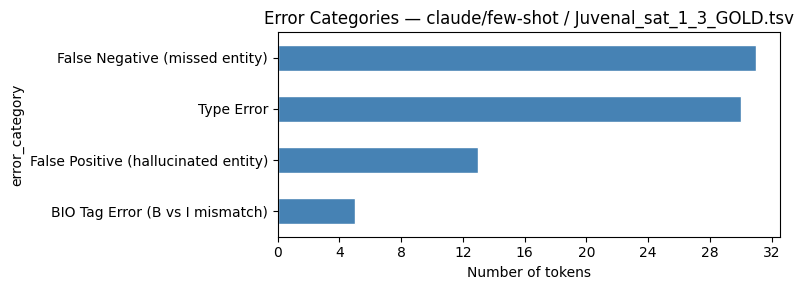

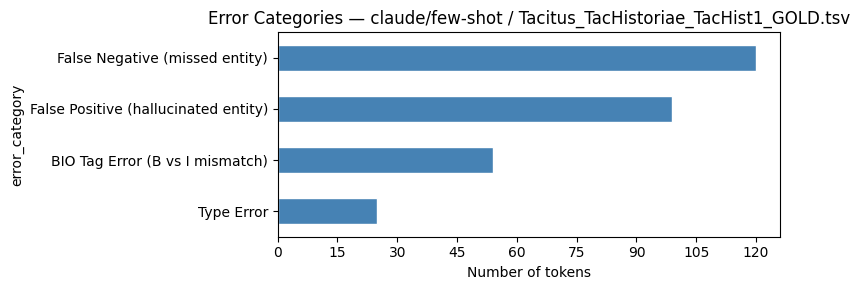

In [15]:
# make bar chart on same stuff
for (model, text) in df_dictionary.keys():
    subset = mistakes_df[
        (mistakes_df['model'] == model) & (mistakes_df['text'] == text)
    ]
    if subset.empty:
        continue

    subset = mistakes_df[
        (mistakes_df['model'] == model) & (mistakes_df['text'] == text)
    ]
    error_counts = subset['error_category'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 3))
    error_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Number of tokens')
    ax.set_title(f'Error Categories — {model} / {text}')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [16]:
# Most common error types per model
for model in mistakes_df['model'].unique():
    subset = mistakes_df[mistakes_df['model'] == model]
    print(f"\n{model}")
    print(subset['error_category'].value_counts().to_string())


latinBERT
error_category
False Negative (missed entity)          419
Type Error                               87
BIO Tag Error (B vs I mismatch)          59
False Positive (hallucinated entity)     23

mBERT
error_category
False Positive (hallucinated entity)    304
Type Error                              294
False Negative (missed entity)          203
BIO Tag Error (B vs I mismatch)         105

mistralNemo/zero-shot
error_category
False Positive (hallucinated entity)    2469
False Negative (missed entity)           715
Type Error                               233
BIO Tag Error (B vs I mismatch)           99

mistralNemo/few-shot
error_category
False Positive (hallucinated entity)    2098
False Negative (missed entity)           813
Type Error                               171
BIO Tag Error (B vs I mismatch)          106

ministral/zero-shot
error_category
False Positive (hallucinated entity)    3350
False Negative (missed entity)           292
Type Error                             

In [17]:
# Most common (gold → pred) confusion pairs among non-O tokens
non_o = mistakes_df[mistakes_df['BIO_gold_norm'] != 'O']
confusion_pairs = (
    non_o
    .groupby(['model', 'text', 'BIO_gold_norm', 'BIO_pred_norm'])
    .size()
    .reset_index(name='count')
    .sort_values(['model', 'text', 'count'], ascending=[True, True, False])
)
print('Top entity-token confusion pairs (gold → pred):')
print(confusion_pairs.to_string(index=False))

Top entity-token confusion pairs (gold → pred):
                model                                      text BIO_gold_norm BIO_pred_norm  count
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv         B-GRP         I-GRP     11
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv         B-GEO             O      5
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv         B-GRP             O      5
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv        B-PERS        I-PERS      3
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv         I-GEO         B-GEO      3
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv        B-PERS         B-GRP      2
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv         I-GRP         B-GRP      2
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv         I-GEO             O      1
      claude/few-shot Cicero_PhilippicaOratio_CicPhi01_GOLD.t

In [18]:
# confusion pairs pivot by model and text
# Aggregate confusion pairs per model (summing across texts)
confusion_by_model = (
    confusion_pairs
    .groupby(['model', 'BIO_gold_norm', 'BIO_pred_norm'])
    ['count']
    .sum()
    .reset_index()
    .loc[lambda df: (df['BIO_gold_norm'] != 'O') & (df['BIO_pred_norm'] != 'O')]
    .sort_values(['model', 'count'], ascending=[True, False])
)

# Pivot to see confusion types as rows, models as columns
confusion_pivot = confusion_by_model.pivot_table(
    index=['BIO_gold_norm', 'BIO_pred_norm'],
    columns='model',
    values='count',
    fill_value=0
)

# Top 5 confusion pairs per model
for model in confusion_pivot.columns:
    top_5 = confusion_pivot[model].nlargest(5)
    print(f"\n{model}")
    for (gold, pred), count in top_5.items():
        print(f"  {gold} → {pred}: {int(count)}")


claude/few-shot
  B-GRP → I-GRP: 26
  I-PERS → B-PERS: 25
  I-GEO → B-GEO: 21
  B-GEO → B-GRP: 16
  B-PERS → B-GRP: 15

claude/zero-shot
  B-GRP → I-GRP: 28
  I-PERS → B-PERS: 23
  I-GEO → B-GEO: 22
  B-GRP → B-GEO: 15
  B-GEO → B-GRP: 13

latinBERT
  B-PERS → I-PERS: 24
  I-GEO → B-GEO: 24
  B-GRP → B-GEO: 23
  B-GRP → B-PERS: 14
  B-GEO → B-GRP: 13

mBERT
  B-GRP → B-GEO: 92
  B-PERS → B-GEO: 54
  B-PERS → I-PERS: 50
  B-GRP → B-PERS: 45
  B-GEO → B-PERS: 39

ministral/few-shot
  I-PERS → B-PERS: 47
  B-GRP → I-GRP: 35
  B-GRP → B-GEO: 31
  B-PERS → B-GEO: 31
  B-PERS → I-PERS: 25

ministral/zero-shot
  B-GRP → B-GEO: 62
  B-PERS → I-PERS: 50
  B-PERS → B-GEO: 47
  B-GRP → I-GRP: 29
  I-PERS → B-PERS: 29

mistralNemo/few-shot
  B-PERS → I-PERS: 39
  B-PERS → B-GEO: 34
  B-GRP → B-GEO: 30
  I-PERS → B-PERS: 26
  B-PERS → B-GRP: 23

mistralNemo/zero-shot
  B-PERS → B-GRP: 66
  B-PERS → B-GEO: 33
  B-PERS → I-PERS: 29
  I-PERS → B-PERS: 25
  B-GRP → I-GRP: 24


## Cross Model

previously: results stored in `token_results` and `span_results`

In [19]:
token_df = pd.DataFrame(token_results)
span_df  = pd.DataFrame(span_results)

summary_df = pd.merge(token_df, span_df, on=['model', 'text'])

numeric_cols = summary_df.select_dtypes(include='number').columns
summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

print('Cross-model summary:')
summary_df

Cross-model summary:


,model,text,token_accuracy,token_precision_macro,token_recall_macro,token_f1_macro,token_f1_weighted,token_f1_B-GRP,token_f1_B-PERS,token_f1_I-PERS,...,token_f1_B-MISC,token_f1_I-MISC,span_precision,span_recall,span_f1,span_f1_GEO,span_f1_GRP,span_f1_PERS,span_f1_DATE,span_f1_MISC
0,latinBERT,Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv,0.9875,0.6294,0.5133,0.5462,0.9852,0.5294,0.8759,0.8780,...,NaN,NaN,0.8875,0.6228,0.7320,0.5455,0.5294,0.8116,NaN,NaN
1,latinBERT,Juvenal_sat_1_3_GOLD.tsv,0.9608,0.4439,0.3225,0.3636,0.9540,0.4918,0.6694,0.0000,...,NaN,NaN,0.7108,0.4354,0.5400,0.3443,0.4839,0.6482,NaN,NaN
2,latinBERT,Tacitus_TacHistoriae_TacHist1_GOLD.tsv,0.9695,0.5954,0.4764,0.5182,0.9655,0.6537,0.8898,0.8459,...,NaN,NaN,0.8376,0.6865,0.7546,0.5479,0.6537,0.8432,0.0,NaN
3,mBERT,Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv,0.9638,0.2978,0.3456,0.3156,0.9699,0.0000,0.7429,0.7778,...,0.0,0.0,0.3667,0.5789,0.4490,0.3333,0.0000,0.6743,NaN,0.0
4,mBERT,Juvenal_sat_1_3_GOLD.tsv,0.9379,0.2433,0.2920,0.2567,0.9455,0.0000,0.6379,0.2069,...,0.0,0.0,0.3989,0.5166,0.4502,0.4472,0.0000,0.5926,NaN,0.0
5,mBERT,Tacitus_TacHistoriae_TacHist1_GOLD.tsv,0.9589,0.3355,0.3338,0.3284,0.9548,0.0000,0.8308,0.7809,...,0.0,0.0,0.6491,0.6079,0.6278,0.5105,0.0000,0.7712,0.0,0.0
6,mistralNemo/zero-shot,Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv,0.8388,0.2035,0.3488,0.2266,0.8900,0.0335,0.3270,0.2316,...,NaN,NaN,0.1129,0.4298,0.1788,0.0777,0.0440,0.3118,NaN,NaN
7,mistralNemo/zero-shot,Juvenal_sat_1_3_GOLD.tsv,0.8163,0.2089,0.3097,0.2273,0.8617,0.0720,0.2931,0.0357,...,NaN,NaN,0.1369,0.3284,0.1933,0.1812,0.0635,0.2850,NaN,NaN
8,mistralNemo/zero-shot,Tacitus_TacHistoriae_TacHist1_GOLD.tsv,0.8255,0.2280,0.2680,0.2352,0.8523,0.1451,0.4513,0.2829,...,NaN,NaN,0.2690,0.3387,0.2999,0.2383,0.1224,0.4192,0.0,NaN
9,mistralNemo/few-shot,Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv,0.8404,0.1823,0.2878,0.1947,0.8885,0.0000,0.2573,0.0915,...,NaN,NaN,0.0975,0.2719,0.1435,0.0962,0.0000,0.2140,NaN,NaN


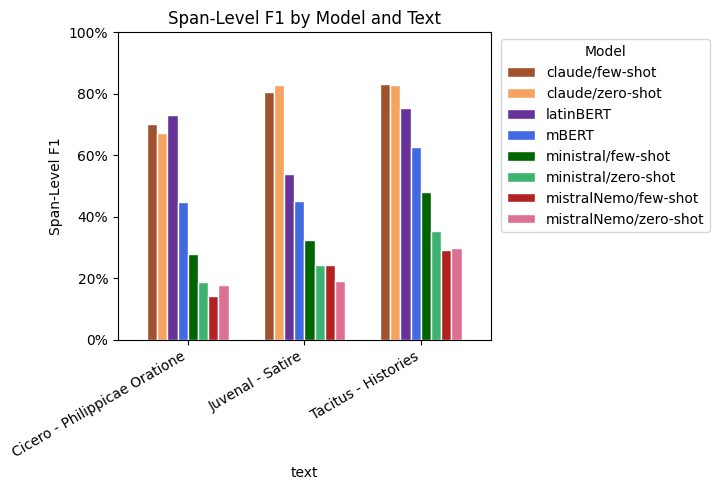

In [20]:
# Grouped bar chart: span F1 per model, grouped by text
pivot = summary_df.pivot(index='text', columns='model', values='span_f1')
plot_colors = [model_color_map[model] for model in pivot.columns]

ax = pivot.plot(
    kind='bar',
    figsize=(max(7, len(TEXT_NAMES) * 2), 5),
    color=plot_colors,
    edgecolor='white',
    width=0.7,
)
ax.set_ylabel('Span-Level F1')
ax.set_title('Span-Level F1 by Model and Text')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks([0, 1, 2], ['Cicero - Philippicae Oratione', 'Juvenal - Satire', 'Tacitus - Histories'],rotation=30, ha='right')
plt.tight_layout()
plt.show()



Average metrics across all texts:
                       token_accuracy  token_f1_weighted  span_precision  span_recall  span_f1
model                                                                                         
claude/few-shot                0.9791             0.9798          0.7709       0.7924   0.7809
claude/zero-shot               0.9786             0.9796          0.7682       0.7858   0.7759
latinBERT                      0.9726             0.9682          0.8120       0.5816   0.6755
mBERT                          0.9535             0.9567          0.4716       0.5678   0.5090
ministral/few-shot             0.8739             0.9047          0.2668       0.5989   0.3614
ministral/zero-shot            0.7996             0.8549          0.1767       0.5473   0.2623
mistralNemo/few-shot           0.8423             0.8750          0.1883       0.3085   0.2268
mistralNemo/zero-shot          0.8269             0.8680          0.1729       0.3656   0.2240


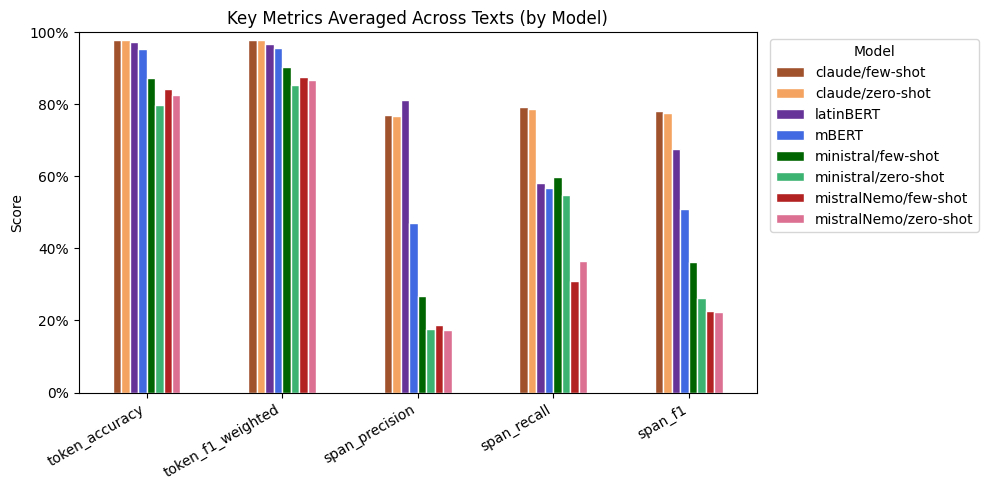

In [21]:
# Key metrics averaged across texts, compared by model
metrics = [
    'token_accuracy', 'token_f1_weighted',
    'span_precision', 'span_recall', 'span_f1'
]
avg_by_model = (
    summary_df
    .groupby('model')[metrics]
    .mean()
    .round(4)
)

print('Average metrics across all texts:')
print(avg_by_model.to_string())

ax = avg_by_model.T.plot(
    kind='bar',
    figsize=(10, 5),
    color=plot_colors,
    edgecolor='white'
)
ax.set_ylabel('Score')
ax.set_title('Key Metrics Averaged Across Texts (by Model)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Just the LLMs

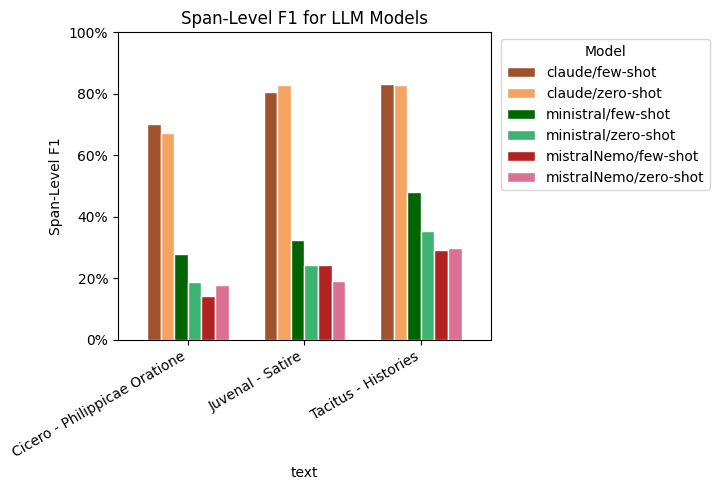

In [22]:
# Get just the LLM models
llm_models = [m for m in MODEL_NAMES if m not in ("latinBERT", "mBERT")]
llm_summary = summary_df[summary_df['model'].isin(llm_models)]

# graph span F1 for just the LLMs
pivot_llm = llm_summary.pivot(index='text', columns='model', values='span_f1')
plot_colors_llm = [model_color_map[model] for model in pivot_llm.columns]
ax = pivot_llm.plot(
    kind='bar',
    figsize=(max(7, len(TEXT_NAMES) * 2), 5),
    color=plot_colors_llm,
    edgecolor='white',
    width=0.7,
)
ax.set_ylabel('Span-Level F1')
ax.set_title('Span-Level F1 for LLM Models')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks([0, 1, 2], ['Cicero - Philippicae Oratione', 'Juvenal - Satire', 'Tacitus - Histories'],rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# improvements in span-level F1 from zero-shot to few-shot
changes_in_f1 = {}
for model_base in set(m.split('/')[0] for m in llm_models):
    zero_f1 = llm_summary[
        (llm_summary['model'] == f"{model_base}/zero-shot")
    ]['span_f1'].mean()
    few_f1  = llm_summary[
        (llm_summary['model'] == f"{model_base}/few-shot")
    ]['span_f1'].mean()
    changes_in_f1[model_base] = few_f1 - zero_f1

print("\nAverage change in span-level F1 from zero-shot to few-shot:")
for model_base, change in changes_in_f1.items():
    print(f"  {model_base}: {change:.4f}")



Average change in span-level F1 from zero-shot to few-shot:
  mistralNemo: 0.0028
  ministral: 0.0991
  claude: 0.0049


## Cross Text

### No significant difference between texts

Average metrics for each text across models:
                                           token_accuracy  token_f1_weighted  span_precision  span_recall  span_f1
text                                                                                                              
Cicero_PhilippicaOratio_CicPhi01_GOLD.tsv          0.9108             0.9368          0.3816       0.5680   0.4182
Juvenal_sat_1_3_GOLD.tsv                           0.8954             0.9169          0.4356       0.5378   0.4538
Tacitus_TacHistoriae_TacHist1_GOLD.tsv             0.9038             0.9164          0.5431       0.5997   0.5589


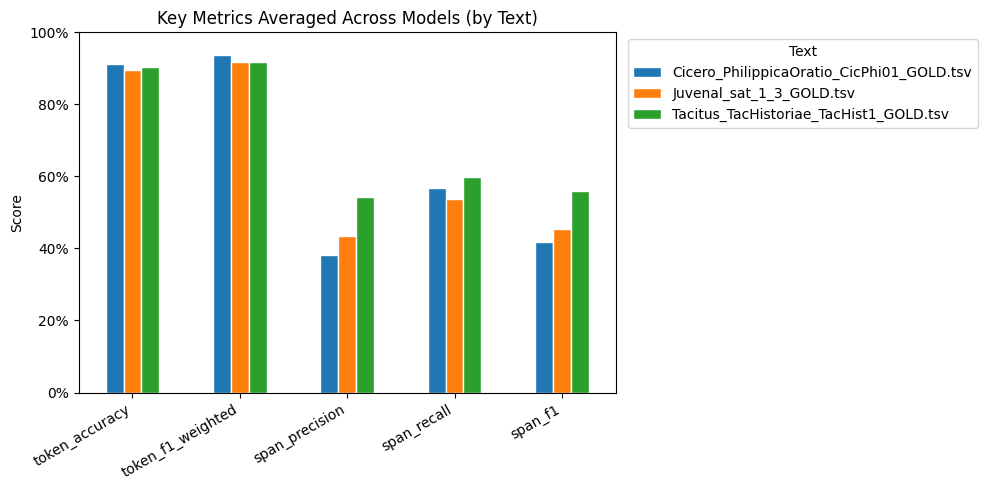

In [24]:
avg_cross_text = (
    summary_df
    .groupby('text')[metrics]
    .mean()
    .round(4)
)

print('Average metrics for each text across models:')
print(avg_cross_text.to_string())

ax = avg_cross_text.T.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor='white'
)
ax.set_ylabel('Score')
ax.set_title('Key Metrics Averaged Across Models (by Text)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Text', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()